# Atmospheric Rivers affecting Pasadena, CA: landfall, frequency, and intensity analysis (1980–2020)

## Overview
Atmospheric rivers (ARs) are narrow, elongated corridors of water vapor that play a major role in the global water cycle {cite}`GuanWaliser:2024`. 
This notebook analyzes how frequently atmospheric rivers of different intensities (AR1–AR5) make landfall within the Pasadena region and how these events vary in intensity and duration over 1980–2020.


This notebook utilizes the PIKART global Lagrangian catalog of atmospheric rivers.

## Prerequisites


| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | Used for geographic plots, map projections, and visualizing AR landfall locations. |
| [Numpy] (https://numpy.org/) | Necessary | Provides fast array operations, masking, and numerical checks used in AR filtering. |
| [Pandas] (https://pandas.pydata.org/) | Necessary | Used to build the AR event table, categorize IVT values, and compute statistics.|
| [Xarray] (https://docs.xarray.dev/en/stable/#)| Essential | Needed for opening ERA5-derived PIKART datasets, selecting variables, and time indexing. |
| [Understanding datetime] (https://docs.python.org/3/library/datetime.html) | Helpful | Useful for handling timestamps from the AR catalog and organizing events by year. |
| [Familirity with Syphon](https://www.unidata.ucar.edu/getting-started-siphon-and-thredds) | Necessary | Required to access the THREDDS catalog and download AR datasets programmatically. |
| Project management | Helpful | |

- **Time to learn**: 35 min.

## Imports

In [1]:
from siphon.catalog import TDSCatalog
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Libraries loaded.")

Libraries loaded.


## Settings

In [2]:
# THREDDS catalog for PIKART lagrangian ERA5
catUrl = "https://ar.pik-potsdam.de/thredds/catalog/lagrangian_era5/catalog.xml"
catalog = TDSCatalog(catUrl)

# Years available in this catalog (lagrangian ERA5: 1980–2020)
years = range(1980, 2021)  # 1980–2020 inclusive

# Pasadena location
pas_lat = 34.156
pas_lon = -118.131

# Coastal window relevant for Pasadena impact
lat_min = 33.5
lat_max = 35.5
lon_min = -121
lon_max = -116

# IVT bins for AR categories (kg/m/s)
ivt_bins = [250, 500, 750, 1000, 1250, 9999]
ivt_labels = ["AR1", "AR2", "AR3", "AR4", "AR5"]

print("Settings configured.")

Settings configured.


## AR Extraction

To assess how atmospheric rivers (ARs) influence Pasadena, I defined a Southern California coastal “landfall window”** and filtered the PIKART dataset to include only ARs that make landfall within this region.  
 
Because ARs are large-scale features, I assume that any AR making landfall inside this window has the potential to affect Pasadena, even if its exact footprint does not pass directly over the city.  
 
A few ARs may influence Pasadena from farther north or south, but these cases are rare and not included here.  

To improve accuracy, I further restricted the dataset to inland-penetrating ARs (`inland_pen == 1`).  
These are events that survive beyond the coastline, ensuring they could realistically deliver moisture into inland regions such as Pasadena.


In [4]:
# Storage for all Pasadena-relevant AR events (all years)
all_years = []
all_trackids = []
all_lf_lat = []
all_lf_lon = []
all_ivt_mag = []
all_duration_hr = []

# LOOP OVER YEARS
for year in years:

    datasetName = f"PIKARTV1_lagrangian_ERA5_0p5deg_6hr_{year}.nc"

    # Skip if this file is not in the catalog
    if datasetName not in catalog.datasets:
        print(f"Year {year}: {datasetName} missing in catalog, skipping.")
        continue

    opendap_url = catalog.datasets[datasetName].access_urls["OPENDAP"]
    print(f"Processing {year} ...")

    ds = xr.open_dataset(opendap_url, engine="netcdf4")

    land_falling = ds["land_falling"]  # (trackid)
    inland_pen = ds["inland_pen"]      # (trackid)
    
     # Select tracks that made landfall AND penetrated inland
    mask_tracks = (land_falling == 1) & (inland_pen == 1)
    inland_land_tracks = ds["trackid"].where(mask_tracks, drop=True)

    if inland_land_tracks.size == 0:
        print(f"  No inland-penetrating landfalling ARs in {year}.")
        ds.close()
        continue

    # Landfall location
    lf = ds["lf_loc"].sel(trackid=inland_land_tracks)  # shape: (time, trackid, coordinate)

    # coordinate=0 - lat, coordinate=1 - lon 
    lat_all = lf.sel(coordinate=0)
    lon_all_360 = lf.sel(coordinate=1)

    # convert longitudes to [-180, 180]
    lon_all = ((lon_all_360 + 180) % 360) - 180

    # Find first landfall time index for each track
    valid = np.isfinite(lat_all) & np.isfinite(lon_all)   # (time, trackid)
    first_idx = valid.argmax(dim="time")                  # index of first True per track

    # Decode CF time to real datetimes
    decoded_time_index = xr.decode_cf(ds)[["time"]].indexes["time"]

    # Loop over each inland landfalling track
    for i in range(inland_land_tracks.size):
        tid = inland_land_tracks[i].item()

        # Skip tracks that have no valid landfall (all False)
        if not bool(valid.sel(trackid=tid).any()):
            continue

        idx = int(first_idx.sel(trackid=tid).item())

        lf_lat = float(lat_all.sel(trackid=tid).isel(time=idx).item())
        lf_lon = float(lon_all.sel(trackid=tid).isel(time=idx).item())

        # Keep only coastal "gateway" landfalls
        if not (lat_min <= lf_lat <= lat_max and lon_min <= lf_lon <= lon_max):
            continue

        # IVT magnitude at landfall: core_ivt(time, trackid, component=0)
        ivt_mag = float(ds["core_ivt"].sel(trackid=tid).isel(time=idx, component=0).item())

        # AR lifetime/duration: lifetime(trackid) [hours]
        if "lifetime" in ds.variables:
            duration_hr = float(ds["lifetime"].sel(trackid=tid).item())
        else:
            # fallback: count how many timesteps exist for this track (each step is 6 hours)
            duration_hr = int(valid.sel(trackid=tid).sum().item()) * 6

        # Landfall time - year (sanity check)
        lf_time = decoded_time_index[idx]
        y = lf_time.year

        all_years.append(y)
        all_trackids.append(tid)
        all_lf_lat.append(lf_lat)
        all_lf_lon.append(lf_lon)
        all_ivt_mag.append(ivt_mag)
        all_duration_hr.append(duration_hr)

    ds.close()

print("Finished extracting Pasadena AR events.")

Processing 1980 ...
Processing 1981 ...
Processing 1982 ...
Processing 1983 ...
Processing 1984 ...
Processing 1985 ...
Processing 1986 ...
Processing 1987 ...
Processing 1988 ...
Processing 1989 ...
Processing 1990 ...
Processing 1991 ...
Processing 1992 ...
Processing 1993 ...
Processing 1994 ...
Processing 1995 ...
Processing 1996 ...
Processing 1997 ...
Processing 1998 ...
Processing 1999 ...
Processing 2000 ...
Processing 2001 ...
Processing 2002 ...
Processing 2003 ...
Processing 2004 ...
Processing 2005 ...
Processing 2006 ...
Processing 2007 ...
Processing 2008 ...
Processing 2009 ...
Processing 2010 ...
Processing 2011 ...
Processing 2012 ...
Processing 2013 ...
Processing 2014 ...
Processing 2015 ...
Processing 2016 ...
Processing 2017 ...
Processing 2018 ...
Processing 2019 ...
Processing 2020 ...
Finished extracting Pasadena AR events.


## Build DataFrame and Categorize ARs

In [5]:
df = pd.DataFrame({
    "year": all_years,
    "trackid": all_trackids,
    "lf_lat": all_lf_lat,
    "lf_lon": all_lf_lon,
    "ivt_mag": all_ivt_mag,
    "duration_hr": all_duration_hr
})

print("Total Pasadena AR events:", len(df))

# Categorize by IVT (AR1–AR5)

df["category"] = pd.cut(df["ivt_mag"], bins=ivt_bins, labels=ivt_labels, right=False)

print(df.head())

Total Pasadena AR events: 39
   year  trackid  lf_lat  lf_lon      ivt_mag  duration_hr category
0  1980  65162.0   33.75  -118.0   645.290222         54.0      AR2
1  1980  65249.0   34.75  -120.5  1222.427246        120.0      AR4
2  1981  67053.0   34.75  -120.5   516.560730         60.0      AR2
3  1981  67309.0   34.75  -120.5   746.231628        102.0      AR2
4  1983  71457.0   34.75  -120.5   744.978882         12.0      AR2


# Visualization

To identify Atmospheric Rivers that can influence Pasadena, we applied a geographic filter selecting ARs whose first landfall occurred within: 32–36°N, –125 to –114°W window.

In the PIKART dataset, landfall is first time the AR polygon intersects any land grid cell. Because the dataset uses a 0.5° grid, coastline cells are coarse and rectangular, so many unrelated ARs end up intersecting the same grid cell as their first landfall. Additionally, ARs often approach Southern California from similar directions.

As a result multiple independent AR events can share the same landfall grid point. 

### 1. Spatial distribution

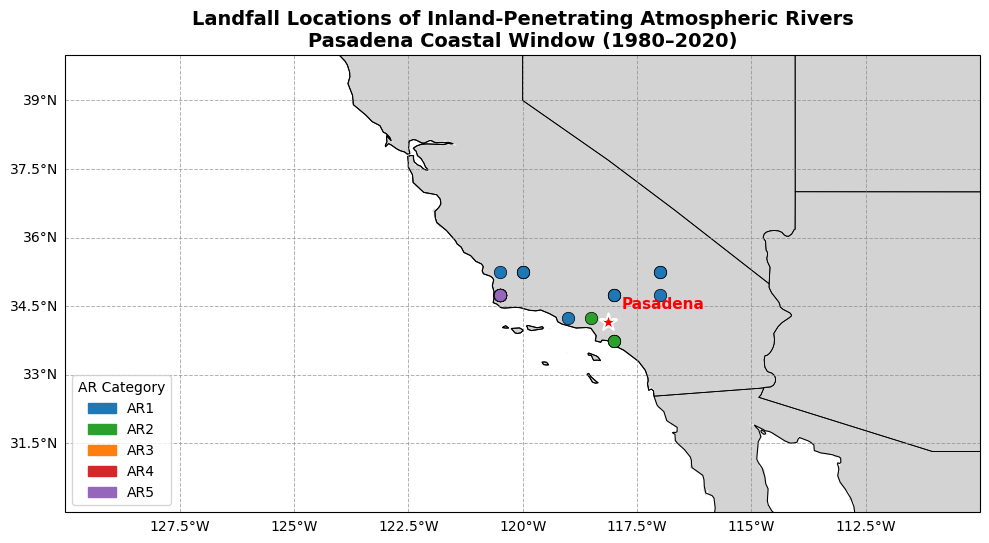

In [6]:
# Color map for categories
color_map = {
    "AR1": "tab:blue",
    "AR2": "tab:green",
    "AR3": "tab:orange",
    "AR4": "tab:red",
    "AR5": "tab:purple"
}

# Filter to only valid rows
df_plot = df.dropna(subset=["lf_lat", "lf_lon", "category"])

# Get colors for plot
colors = df_plot["category"].map(color_map).astype(str).values

# plot
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Southern California region
ax.set_extent([-130, -110, 30, 40], crs=ccrs.PlateCarree())

# Base map features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8)
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Scatter points for AR landfall, layered by category
cat_order = ["AR1", "AR2", "AR3", "AR4", "AR5"]

for cat in cat_order:
    sub = df_plot[df_plot["category"] == cat]
    ax.scatter(
        sub["lf_lon"],
        sub["lf_lat"],
        c=color_map[cat],
        s=80,
        edgecolor="black",
        linewidth=0.5,
        transform=ccrs.PlateCarree(),
        zorder=3,
        label=cat  
    )

# Pasadena reference point
ax.scatter(
    pas_lon, pas_lat,
    color="red",
    s=170,
    edgecolor="white",
    linewidth=1.5,
    marker="*",
    transform=ccrs.PlateCarree(),
    zorder=4
)

ax.text(
    pas_lon + 0.3, pas_lat + 0.3,
    "Pasadena",
    fontsize=11,
    fontweight="bold",
    color="red",
    transform=ccrs.PlateCarree(),
    zorder=4
)

# Gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.7,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

# Legend for categories
legend_patches = [
    mpatches.Patch(color=color_map[cat], label=cat)
    for cat in color_map
]
plt.legend(handles=legend_patches, title="AR Category", loc="lower left")

# Title
ax.set_title(
    "Landfall Locations of Inland-Penetrating Atmospheric Rivers\nPasadena Coastal Window (1980–2020)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



### 2. Duration vs. Intensity

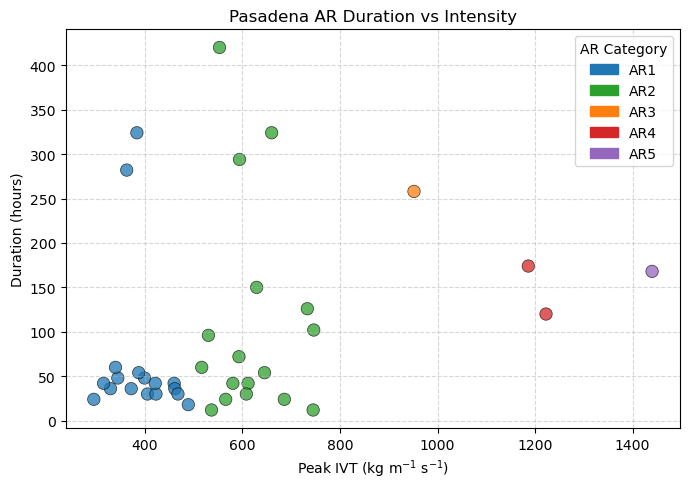

In [9]:
df_plot = df.dropna(subset=["ivt_mag", "duration_hr", "category"])
order = ["AR1", "AR2", "AR3", "AR4", "AR5"]


plt.figure(figsize=(7, 5))
plt.scatter(df_plot["ivt_mag"],
            df_plot["duration_hr"],
            c=df_plot["category"].map(color_map),
            s=80, edgecolor="black", linewidth=0.5, alpha=0.75)

plt.title("Pasadena AR Duration vs Intensity")
plt.xlabel("Peak IVT (kg m$^{-1}$ s$^{-1}$)")
plt.ylabel("Duration (hours)")
plt.grid(True, linestyle="--", alpha=0.5)

legend_handles = [mpatches.Patch(color=color_map[c], label=c) for c in order]
plt.legend(handles=legend_handles, title="AR Category")

plt.tight_layout()
plt.show()


### 3. Pasadena AR frequency per year

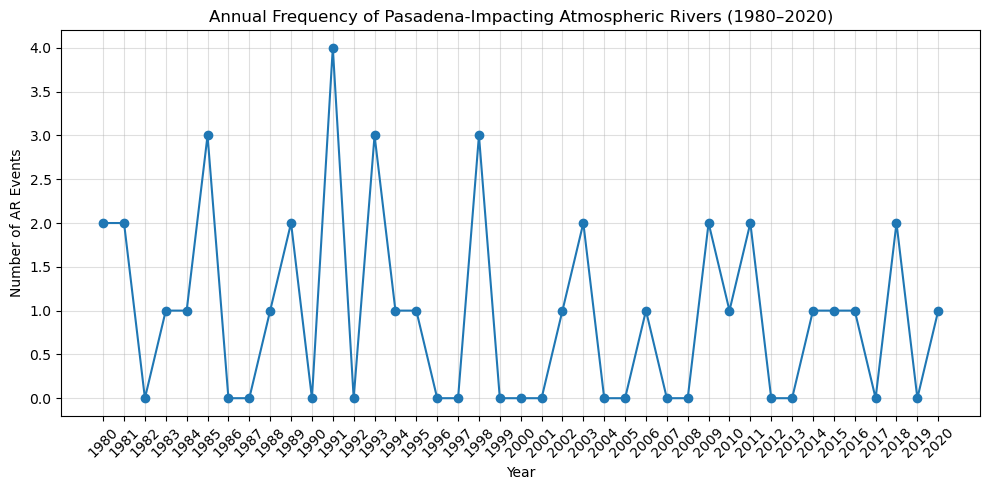

In [10]:
all_years = np.arange(1980, 2021)

# Count AR events and insert zeros for years with no events
counts = df.groupby("year").size().reindex(all_years, fill_value=0)

plt.figure(figsize=(10,5))
plt.plot(all_years, counts.values, marker="o", linestyle="-", color="tab:blue")

plt.title("Annual Frequency of Pasadena-Impacting Atmospheric Rivers (1980–2020)")
plt.xlabel("Year")
plt.ylabel("Number of AR Events")
plt.grid(True, alpha=0.4)

plt.xticks(all_years, rotation=45)
plt.tight_layout()
plt.show()


### 4. Frequency of AR Categories

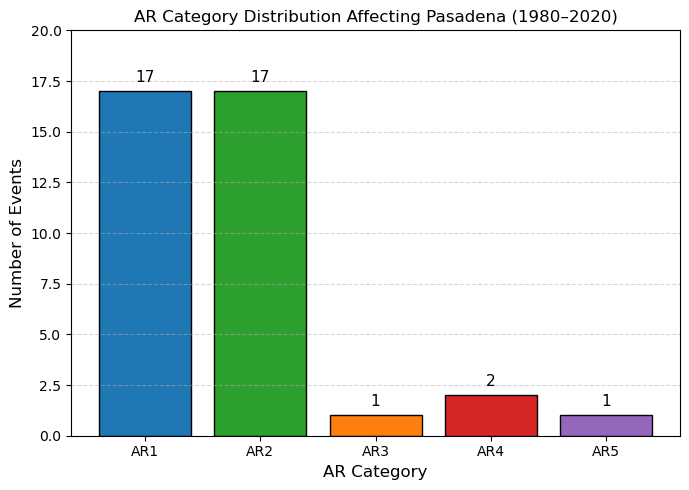

In [12]:
cat_counts = df_plot["category"].value_counts().reindex(order, fill_value=0)

plt.figure(figsize=(7, 5))
bars = plt.bar(order,
               cat_counts.values,
               color=[color_map[c] for c in order],
               edgecolor="black",
               linewidth=1)

plt.title("AR Category Distribution Affecting Pasadena (1980–2020)")
plt.xlabel("AR Category", fontsize=12)
plt.ylabel("Number of Events", fontsize=12)

# Add labels above bars
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.3,
             f"{int(h)}",
             ha="center",
             va="bottom",
             fontsize=11)

# Expand y-axis so labels fit
plt.ylim(0, cat_counts.max() + 3)   # *** KEY FIX ***

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



:::{note}
AR categories in this notebook follow simple IVT thresholds (250–1250+ kg m⁻¹ s⁻¹).  
These thresholds approximate the scale used in Atmospheric River categories follow <a href="https://doi.org/10.1175/BAMS-D-18-0023.1" target="_blank" style="color:#1f77b4;">
Ralph et al. (2019)
</a> but are applied here directly to core IVT values from the dataset.
:::


:::{warning}
Extracting AR variables can be computationally expensive.  
This process may take several minutes, depending on network speed and the number of years analyzed.
:::


## Summary

In this notebook, I worked with the PIKART global atmospheric river catalog to study AR events affecting Pasadena, California from 1980 to 2020. I identified which AR tracks made landfall within the Pasadena window and extracted key characteristics such as IVT intensity and event duration. Each AR was then categorized on the AR1–AR5 scale. Using these data, I created a 40-year climatology that includes annual AR frequency, intensity–duration patterns, and spatial landfall maps generated with Cartopy. Together, these analyses show how often ARs reach Pasadena, how strong they are, and how these events have changed over time.

## References

Ralph, F. M., Rutz, J. J., Cordeira, J. M., Dettinger, M. D., Anderson, M. B., Reynolds, D. W., … Smallcomb, C. (2019). A scale to characterize the strength and impacts of atmospheric rivers. Bulletin of the American Meteorological Society, 100(2), 269–289